## Campaign for selling personal loans.

This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

The file Bank_Personal_Loan_Modelling.csvView in a new window  contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

* Follow the instructions below and create a python notebook to attempt the same :

1. Read the column description and ensure you understand each attribute well
2. Study the data distribution in each attribute, share your findings. (5 points)
3. Get the target column distribution. Your comments (5 points)
4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)
5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)
6. Print the confusion matrix for all the above models (10 points)
7. Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [1]:
#import the python libraries

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cross_validation import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
from sklearn.metrics import f1_score, auc, roc_curve

from scipy.stats import zscore

/usr/lib/python3/dist-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/usr/lib/python3/dist-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [4]:
#Import graph plotting libraries
import matplotlib as mp
import seaborn as sns
%matplotlib inline
sns.set(style="ticks")

## 1. Read the column description and ensure you understand each attribute well

In [5]:
df = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")

In [6]:
df.shape

(5000, 14)

In [7]:
#print some random rows
df.sample(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
521,522,48,24,75,92518,4,1.40,2,0,0,0,0,1,0
3687,3688,34,10,45,93943,1,1.33,1,0,0,0,0,0,0
1363,1364,32,8,79,92115,1,0.10,1,0,0,0,0,0,0
1925,1926,43,19,81,90245,1,0.30,1,218,0,0,0,1,0
4302,4303,52,27,85,92037,3,3.40,3,0,1,0,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [9]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Observations

In [10]:
# Min experience is showing negative value -3, which is incorrect, so we have to update the
# negative values in that column with median

## Remove Negative Experiences

In [11]:
df_exp = df.loc[df['Experience'] >0]
mask = df.Experience < 0
id_list = df.loc[mask]['ID'].tolist()

In [12]:
#Replace with median values
for id in id_list:
    age = df.loc[np.where(df['ID']==id)]["Age"].tolist()[0]
    education = df.loc[np.where(df['ID']==id)]["Education"].tolist()[0]
    df_filtered = df_exp[(df_exp.Age == age) & (df_exp.Education == education)]
    df.loc[df.loc[np.where(df['ID']==id)].index, 'Experience'] = df_filtered['Experience'].median()

In [13]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,4971.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.243211,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.359189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## 2. Study the data distribution in each attribute, share your findings. (5 points)

/home/siju/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/siju/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1.0,49,91107,4,1.6,1,0,0,1,0,0,0


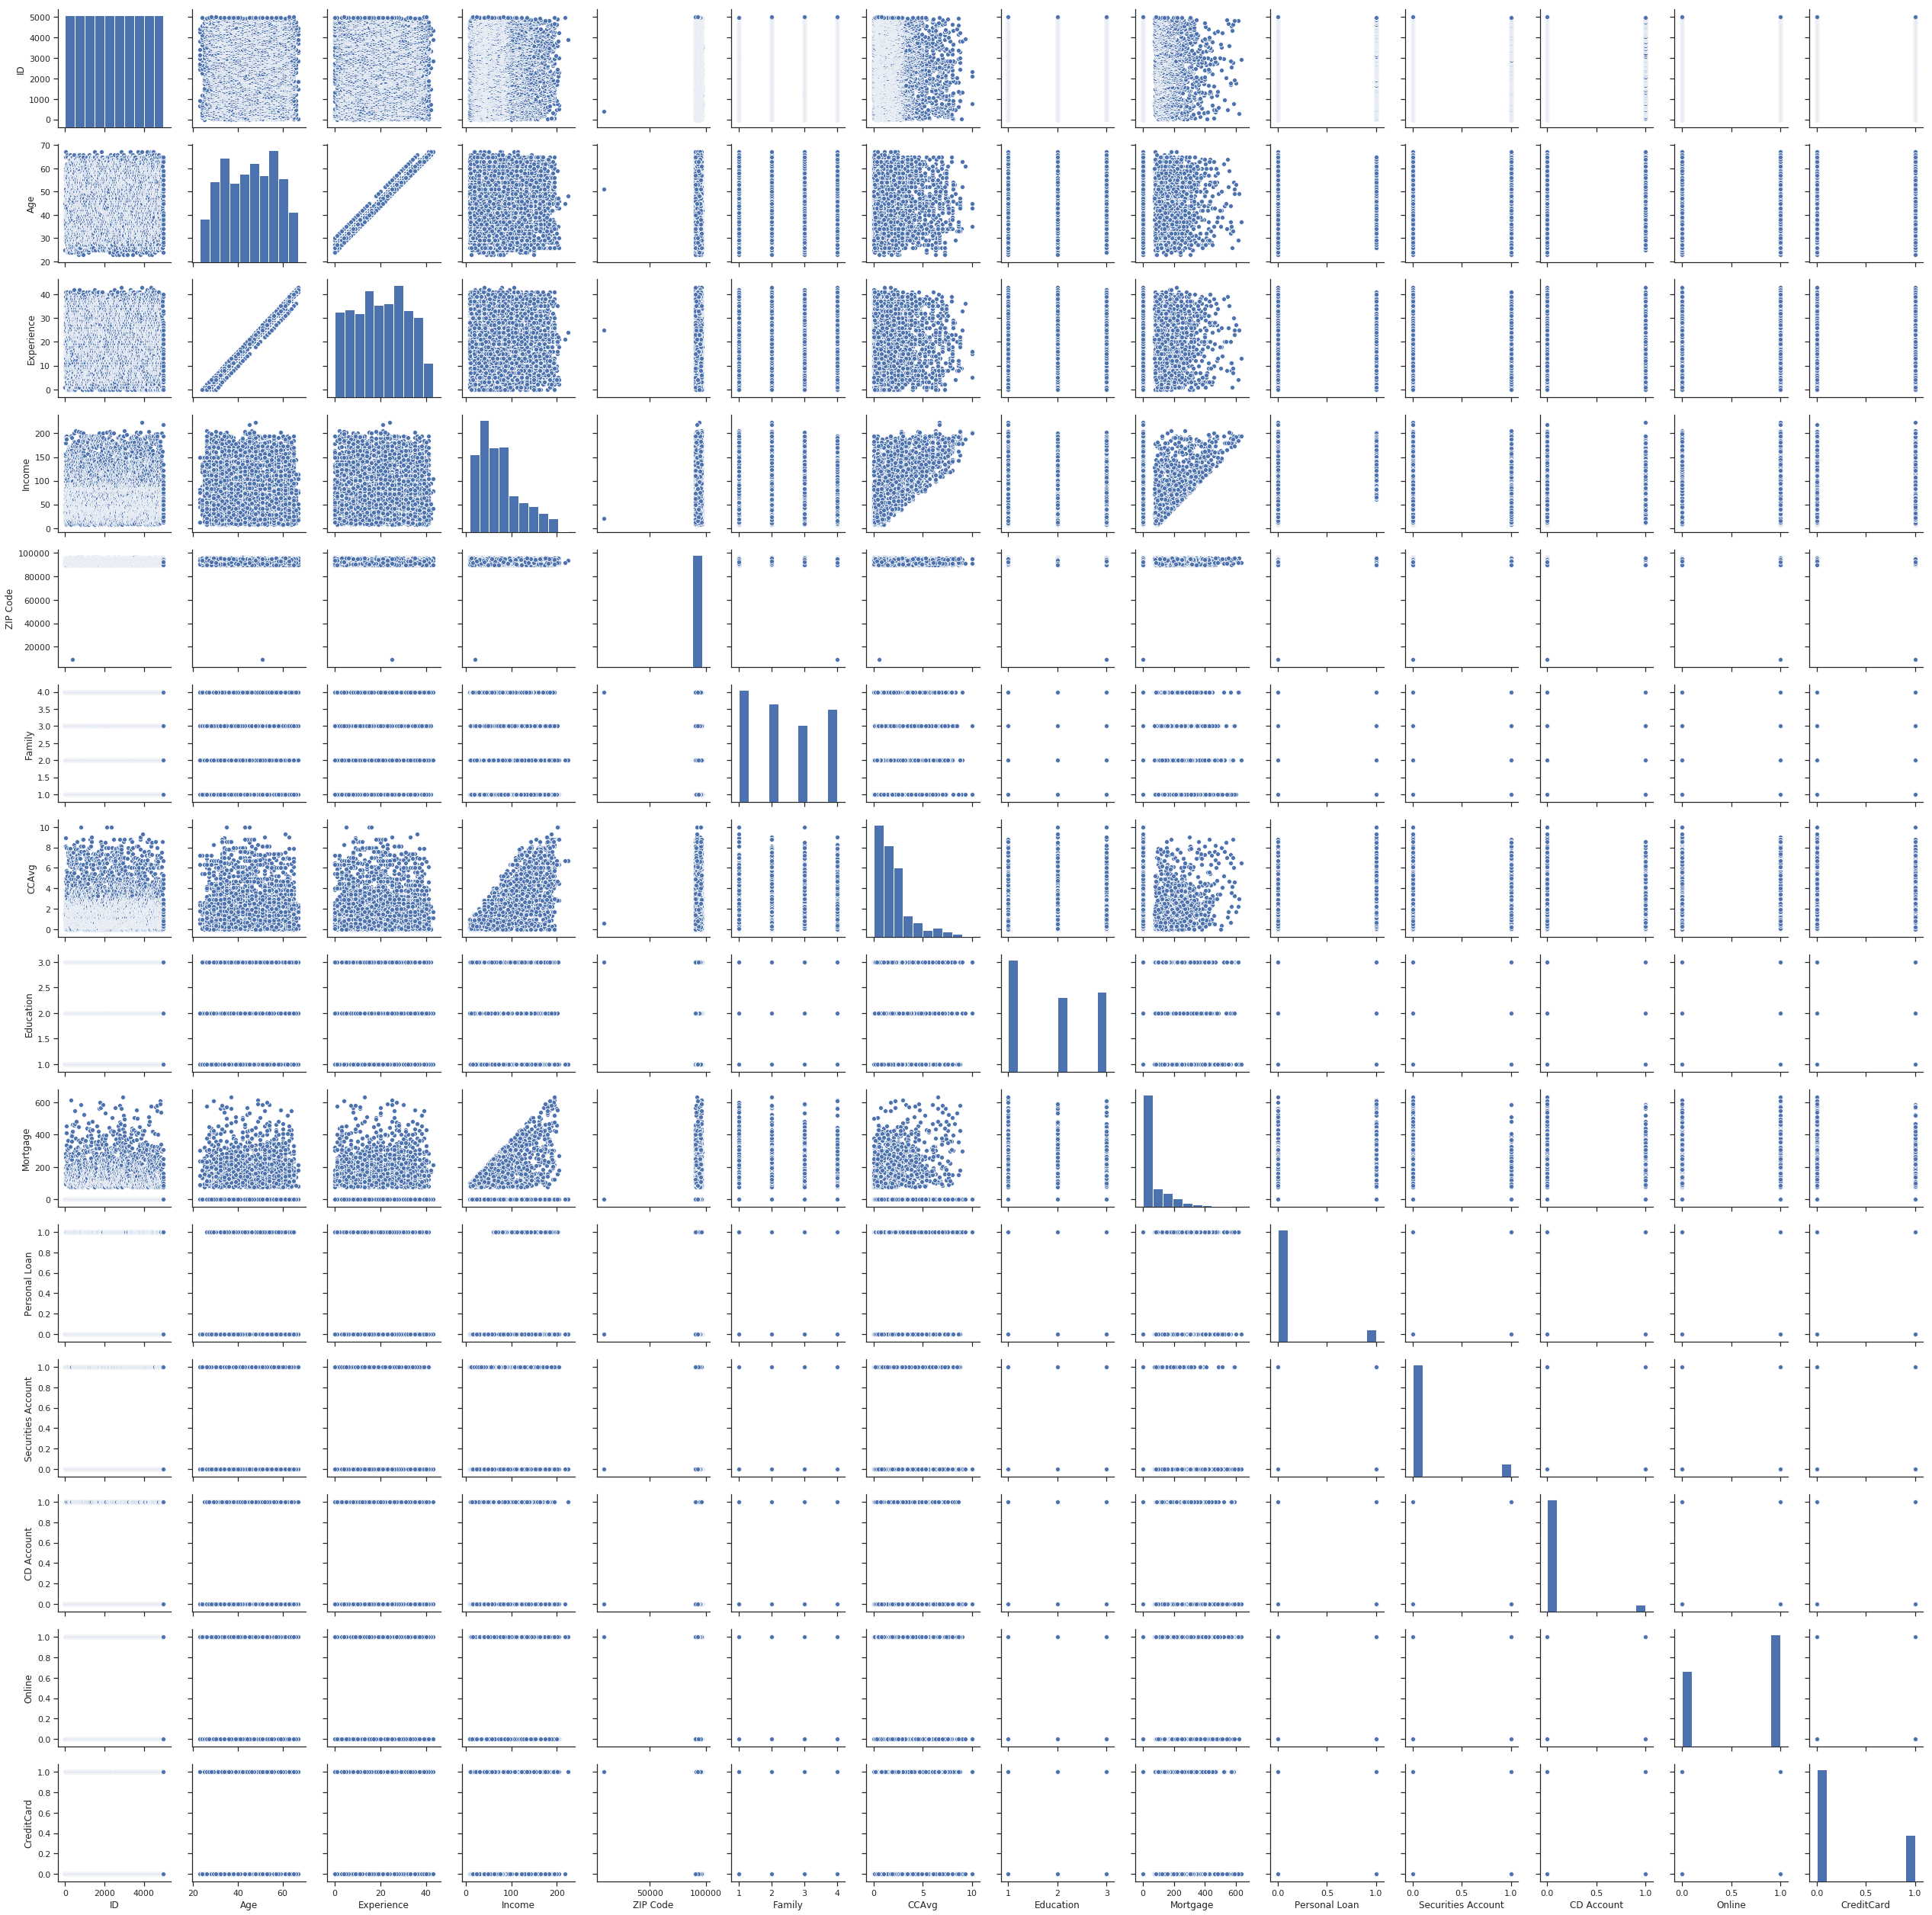

In [14]:
sns.pairplot(df)
df.head(1)

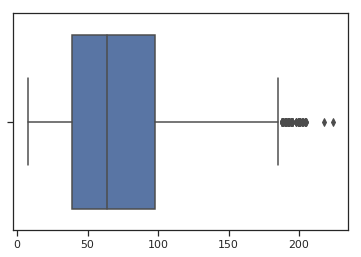

In [15]:
plt = sns.boxplot(df[['Income']])

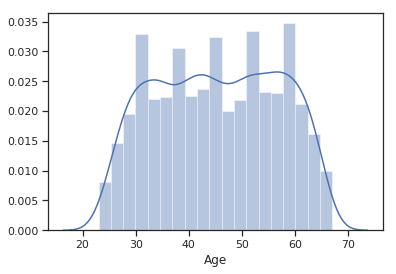

In [16]:
sns.distplot( df['Age'])

## Observation

#### Most of the customers age fall in the age range of 30 to 60 yrs and their experience falls in the range of 5 to 35 years and most earn an income between 10K to 100K.

## what is the influence of Income level on whether a customer takes a personal loan across the education levels.¶

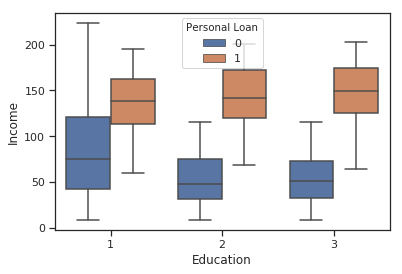

In [17]:
sns.boxplot(x="Education", y="Income", hue="Personal Loan", data=df)

## Observation
The box plots show that those with education level 1 have higher incomes. But customers who go for personal loans have the same income distribution regardless of the education level.

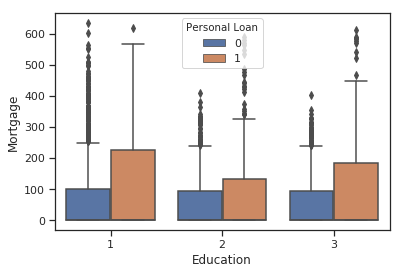

In [18]:
sns.boxplot(x="Education", y='Mortgage', hue="Personal Loan", data=df)

## Observation
Customers who taken loan also have higher mortgages.

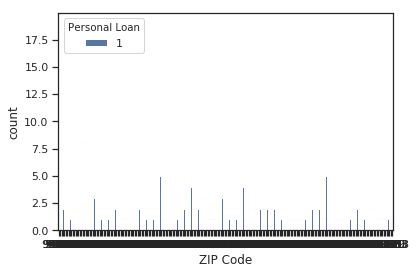

In [19]:
sns.countplot(x="ZIP Code", data=df[df['Personal Loan']==1], hue ="Personal Loan",orient ='v')

## Observation
Top 5 locations who appled personal loan before

In [20]:
df[df['Personal Loan']==1]['ZIP Code'].value_counts().head(5)

94720    19
94305    13
92093     9
90095     8
90089     8
Name: ZIP Code, dtype: int64

In [21]:
## Does family size have any influence on whether a customer accepts a personal loan offer?¶

In [22]:
familysize_no = np.mean( df[df['Personal Loan'] == 0]['Family'] )
familysize_no

2.3734513274336284

In [23]:
familysize_yes = np.mean( df[df['Personal Loan'] == 1]['Family'] )
familysize_yes

2.6125

In [24]:
from scipy import stats

stats.ttest_ind(df[df['Personal Loan'] == 1]['Family'], df[df['Personal Loan'] == 1]['Family'])


Ttest_indResult(statistic=0.0, pvalue=1.0)

## Observation¶
Family size seems to have no impact on decision to take a loan.

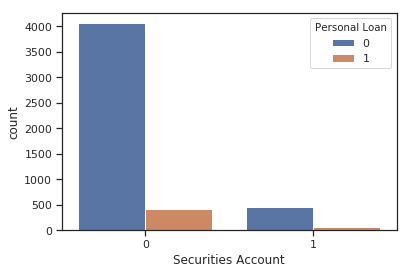

In [25]:
sns.countplot(x="Securities Account", data=df,hue="Personal Loan")


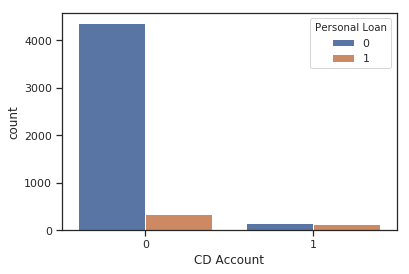

In [26]:
sns.countplot(x="CD Account", data=df,hue="Personal Loan")

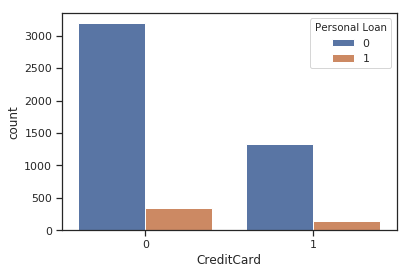

In [27]:
sns.countplot(x="CreditCard", data=df,hue="Personal Loan")

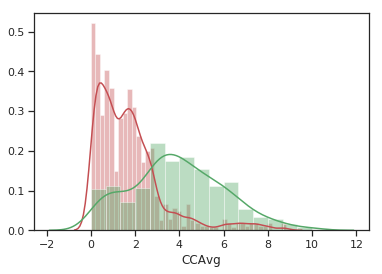

In [28]:
sns.distplot( df[df['Personal Loan'] == 0]['CCAvg'], color = 'r')
sns.distplot( df[df['Personal Loan'] == 1]['CCAvg'], color = 'g')

## Observation
Customers who have taken personal loan have higher credit card average than those who did not take. So high credit card average seems to be good predictor of whether or not a customer will take a personal loan.

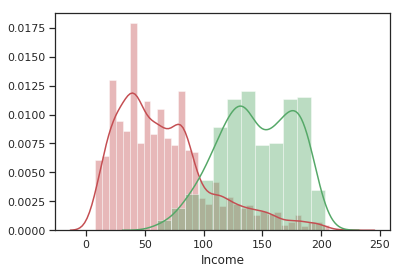

In [29]:
sns.distplot( df[df['Personal Loan'] == 0]['Income'], color = 'r')
sns.distplot( df[df['Personal Loan'] == 1]['Income'], color = 'g')

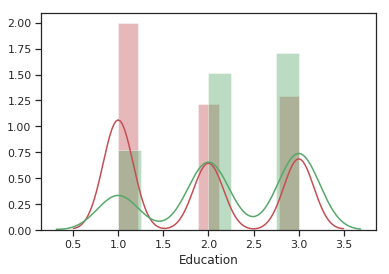

In [30]:
sns.distplot( df[df['Personal Loan'] == 0]['Education'], color = 'r')
sns.distplot( df[df['Personal Loan'] == 1]['Education'], color = 'g')

## Correlation comparison with heat map¶

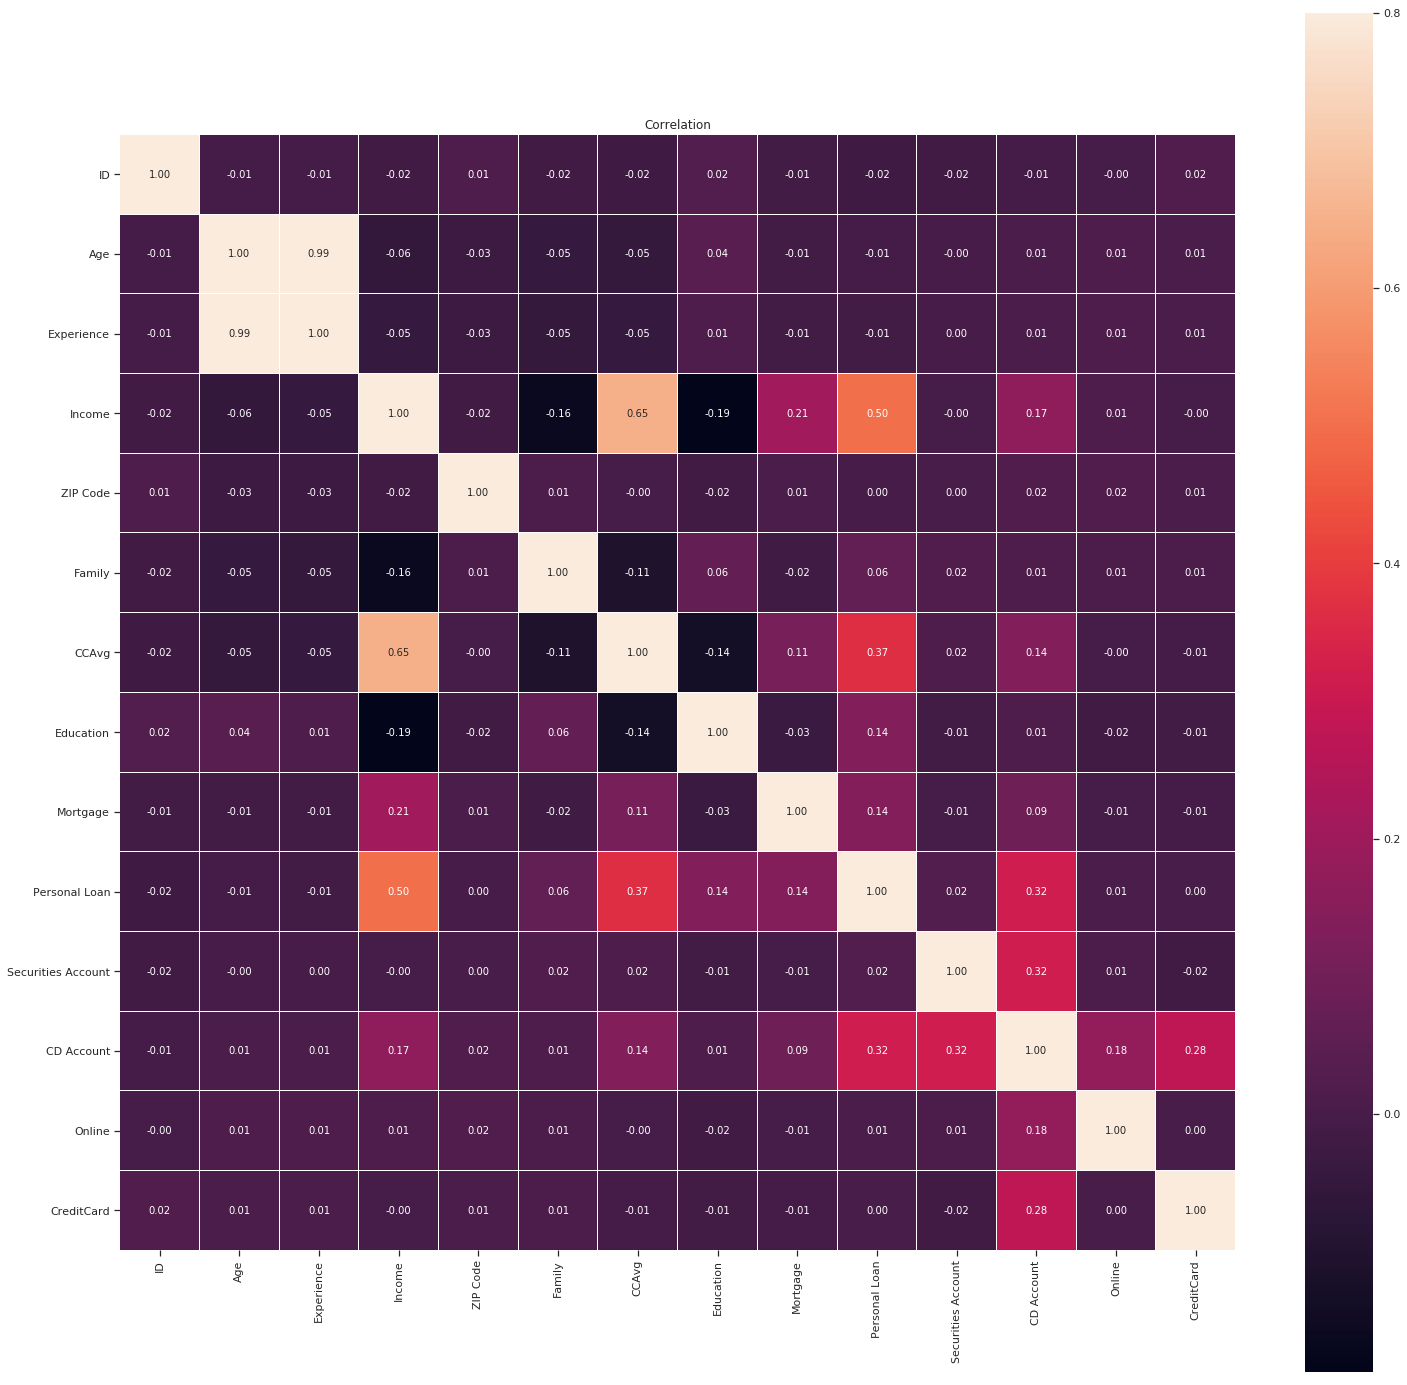

In [31]:
from matplotlib import pyplot as plt
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

## Observation
1. Age and Experience is highly corelated
2. Income and CCAvg also corelated

## 3. Get the target column distribution. Your comments (5 points)

In [32]:
df.groupby(["Personal Loan"]).count()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,4520,4520,4491,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480,480,480


In [33]:
x = df['Personal Loan'].value_counts()
x

0    4520
1     480
Name: Personal Loan, dtype: int64

In [34]:
x[0]/x[1]

9.416666666666666

### Observation

In [35]:
# Most peple doesnt take personal loan. The ratio is almost 1:9 in favor or class 0.  
# The model's ability to predict class 0 will be better than predicting class 1. 

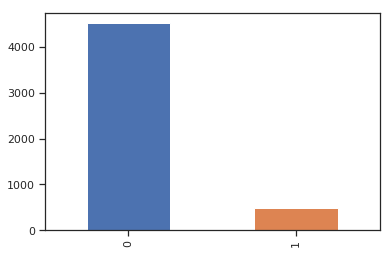

In [36]:
x.plot.bar()

## 4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [37]:
#Drop highly correlated columns
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df.drop(['Experience' ,'ID' ,'CCAvg'], axis=1), test_size=0.3 , random_state=0)
train_labels = train_set.pop("Personal Loan")
test_labels = test_set.pop("Personal Loan")

In [38]:
train_set.describe()

,Age,Income,ZIP Code,Family,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,45.274857,74.053714,93152.619143,2.417429,1.874857,55.563714,0.108000,0.062571,0.594000,0.292857
std,11.477448,46.254573,1755.660581,1.159123,0.835615,99.975574,0.310425,0.242225,0.491155,0.455138
min,23.000000,8.000000,90005.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,64.000000,93407.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,55.000000,99.000000,94596.000000,4.000000,3.000000,99.000000,0.000000,0.000000,1.000000,1.000000
max,67.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
test_set.describe()

,Age,Income,ZIP Code,Family,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
count,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,45.486667,73.12200,93152.232000,2.347333,1.895333,58.680667,0.096000,0.055333,0.603333,0.296667
std,11.432218,45.52291,2796.364193,1.119313,0.849819,105.660450,0.294689,0.228706,0.489369,0.456941
min,23.000000,8.00000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,39.00000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46.000000,63.00000,93711.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,55.000000,94.00000,94708.000000,3.000000,3.000000,103.250000,0.000000,0.000000,1.000000,1.000000
max,67.000000,218.00000,96651.000000,4.000000,3.000000,601.000000,1.000000,1.000000,1.000000,1.000000


## 5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

In [40]:
## Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
def add_row(df, row):
    df.loc[-1] = row
    df.index = df.index + 1  
    return df.sort_index()
result = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "Precision", "F1-Score", "Confusion Matrix"])

In [43]:
lr = LogisticRegression()
lr.fit(train_set, train_labels)
prediction = lr.predict(test_set)
print("Accuracy Score = ", lr.score(test_set, test_labels))
cm_lr = confusion_matrix(prediction, test_labels)
print(cm_lr)
testAccuracy = accuracy_score(test_labels, prediction)
testRecall = recall_score(test_labels, prediction)
testPrecision = precision_score(test_labels, prediction)
testF1score = f1_score(test_labels, prediction)
print(testAccuracy, testRecall, testPrecision, testF1score)
result = add_row(result, ["Logistic", testAccuracy, testRecall, testPrecision, testF1score, cm_lr])

Accuracy Score =  0.918
[[1329   80]
 [  43   48]]
0.918 0.375 0.5274725274725275 0.4383561643835617


## K-Nearest Neighbor

In [44]:
train_set_z = train_set.apply(zscore)  # convert all attributes to Z scale 
test_set_z = test_set.apply(zscore)  # convert all attributes to Z scale 

In [45]:
recall = 0
for n in range(1, 20, 2):
    knn = KNeighborsClassifier(n_neighbors= n)
    # Call Nearest Neighbour algorithm
    knn.fit(train_set_z, train_labels)
    prediction = knn.predict(test_set_z)
    tmp = recall_score(test_labels, prediction)
    if (tmp > recall):
        #print("Accuracy Score = ", knn.score(test_set_z, test_labels))
        cm_knn = confusion_matrix(prediction, test_labels)
        #print(cm_knn)
        testAccuracy = accuracy_score(test_labels, prediction)
        testRecall = recall_score(test_labels, prediction)
        testPrecision = precision_score(test_labels, prediction)
        testF1score = f1_score(test_labels, prediction)
print(n, testAccuracy, testRecall, testPrecision, testF1score)
result = add_row(result, ["knn n=" + str(n), testAccuracy, testRecall, testPrecision, testF1score, cm_knn])

19 0.9566666666666667 0.5078125 0.9701492537313433 0.6666666666666667


## Naive Bayes

In [46]:
naive_model = GaussianNB()
naive_model.fit(train_set, train_labels)

prediction = naive_model.predict(test_set)
naive_model.score(test_set, test_labels)

0.9013333333333333

In [47]:
cm_nb = confusion_matrix(prediction, test_labels)
print(cm_nb)
testAccuracy = accuracy_score(test_labels, prediction)
testRecall = recall_score(test_labels, prediction)
testPrecision = precision_score(test_labels, prediction)
testF1score = f1_score(test_labels, prediction)
print(n, testAccuracy, testRecall, testPrecision, testF1score, cm_nb)

[[1291   67]
 [  81   61]]
19 0.9013333333333333 0.4765625 0.4295774647887324 0.45185185185185184 [[1291   67]
 [  81   61]]


In [48]:
result = add_row(result, ["Naive Bayes", testAccuracy, testRecall, testPrecision, testF1score, cm_nb])

## 6. Print the confusion matrix for all the above models (10 points)

In [49]:
### Analyzing the confusion matrix
def analyze_confusion_matrix(cm):
    print("True Positives (TP): we correctly predicted that they need Personal Loan ", cm[1][1])
    print("True Negatives (TN): we correctly predicted that they don't need Personal Loan ", cm[0][0])
    print("False Positives (FP): we incorrectly predicted that they do need Personal Loan (a Type I error) ", cm[0][1])
    print("Falsely predict positive Type I error")
    print("False Negatives (FN): we incorrectly predicted that they don't need Personal Loan (a Type II error) ", cm[1][0])
    print("Falsely predict negative Type II error")
    
def print_cm(cm):
    con_mat = pd.DataFrame(cm, index=['Yes', 'No'], columns=['Yes', 'No'])
    con_mat.index.name = 'Predicted |'
    con_mat.columns.name = 'Actual --'
    return con_mat

In [50]:
#### Confusion Matrix of Logistic

In [51]:
print_cm(cm_lr)

Actual --,Yes,No
Predicted |,,
Yes,1329,80
No,43,48


In [52]:
analyze_confusion_matrix(cm_lr)

True Positives (TP): we correctly predicted that they need Personal Loan  48
True Negatives (TN): we correctly predicted that they don't need Personal Loan  1329
False Positives (FP): we incorrectly predicted that they do need Personal Loan (a Type I error)  80
Falsely predict positive Type I error
False Negatives (FN): we incorrectly predicted that they don't need Personal Loan (a Type II error)  43
Falsely predict negative Type II error


In [53]:
#### Confusion Matrix of KNN

In [54]:
print_cm(cm_knn)

Actual --,Yes,No
Predicted |,,
Yes,1370,63
No,2,65


In [55]:
analyze_confusion_matrix(cm_knn)

True Positives (TP): we correctly predicted that they need Personal Loan  65
True Negatives (TN): we correctly predicted that they don't need Personal Loan  1370
False Positives (FP): we incorrectly predicted that they do need Personal Loan (a Type I error)  63
Falsely predict positive Type I error
False Negatives (FN): we incorrectly predicted that they don't need Personal Loan (a Type II error)  2
Falsely predict negative Type II error


In [56]:
#### Confusion Matrix of Naive Bayes

In [57]:
print_cm(cm_nb)

Actual --,Yes,No
Predicted |,,
Yes,1291,67
No,81,61


In [58]:
analyze_confusion_matrix(cm_nb)

True Positives (TP): we correctly predicted that they need Personal Loan  61
True Negatives (TN): we correctly predicted that they don't need Personal Loan  1291
False Positives (FP): we incorrectly predicted that they do need Personal Loan (a Type I error)  67
Falsely predict positive Type I error
False Negatives (FN): we incorrectly predicted that they don't need Personal Loan (a Type II error)  81
Falsely predict negative Type II error


## 7. Give your reasoning on which is the best model in this case and why it performs better? (10 points)

#### Print and check each model parameters

In [59]:
result

,Model,Accuracy,Recall,Precision,F1-Score,Confusion Matrix
0,Naive Bayes,0.901333,0.476562,0.429577,0.451852,"[[1291, 67], [81, 61]]"
1,knn n=19,0.956667,0.507812,0.970149,0.666667,"[[1370, 63], [2, 65]]"
2,Logistic,0.918000,0.375000,0.527473,0.438356,"[[1329, 80], [43, 48]]"


#### Check which model got highest Accuracy, Recall, Precision & F1 Score

In [60]:
max_acc = result.iloc[result['Accuracy'].idxmax()].Model
max_rec = result.iloc[result['Recall'].idxmax()].Model
max_pre = result.iloc[result['Precision'].idxmax()].Model
max_f1s = result.iloc[result['F1-Score'].idxmax()].Model

In [61]:
print("Maximum Accuracy", max_acc)
print("Maximum Recall", max_rec)
print("Maximum Precision", max_pre)
print("Maximum F1-Score", max_f1s)

Maximum Accuracy knn n=19
Maximum Recall knn n=19
Maximum Precision knn n=19
Maximum F1-Score knn n=19


#### KNN shows high accuracy, precision, recall and F1 Score compared to Naive Bayes and Logistic.
#### K Nearest Neighbor is the best model for this scenario. KNN is a non-parametric, lazy learning algorithm. An object is classified by a majority vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors

#### 1. k-NN performs much better if all of the data have the same scale
#### 2. k-NN works well with a small number of input variables, but struggles when the number of inputs is very large
#### 3. k-NN makes no assumptions about the functional form of the problem being solved
